In [7]:
from pathlib import Path
from IPython.display import HTML, display
import pandas as pd
import plotly.express as px

# 1. Carrega os dados
caminho = (
    Path("artigos.parquet")
    if Path("artigos.parquet").exists()
    else Path("../data/exemplo/artigos.parquet")
)
df = pd.read_parquet(caminho)

col_pesquisador = (
    "pesquisador" if "pesquisador" in df.columns else "nome_completo"
)

# 2. Agrupamento hierárquico (Pesquisador -> Ano)
df_agrupado = (
    df.groupby([col_pesquisador, "ano"]).size().reset_index(name="quantidade")
)

# 3. Construção do Treemap
fig = px.treemap(
    df_agrupado,
    path=[col_pesquisador, "ano"],
    values="quantidade",
    title="Proporção de Publicações por Pesquisador e Ano",
)

# 4. Renderização direta em HTML (Bypassa o erro de nbformat no fig.show())
display(HTML(fig.to_html(include_plotlyjs="cdn")))

**Análise do Treemap (Proporções Hierárquicas):**
* **Área dos Retângulos:** A área proporcional de cada bloco reflete a participação do docente no total de publicações da equipe.
* **Detalhamento Aninhado:** Os retângulos internos mapeiam como a produção de cada pesquisador está distribuída individualmente ao longo dos anos.

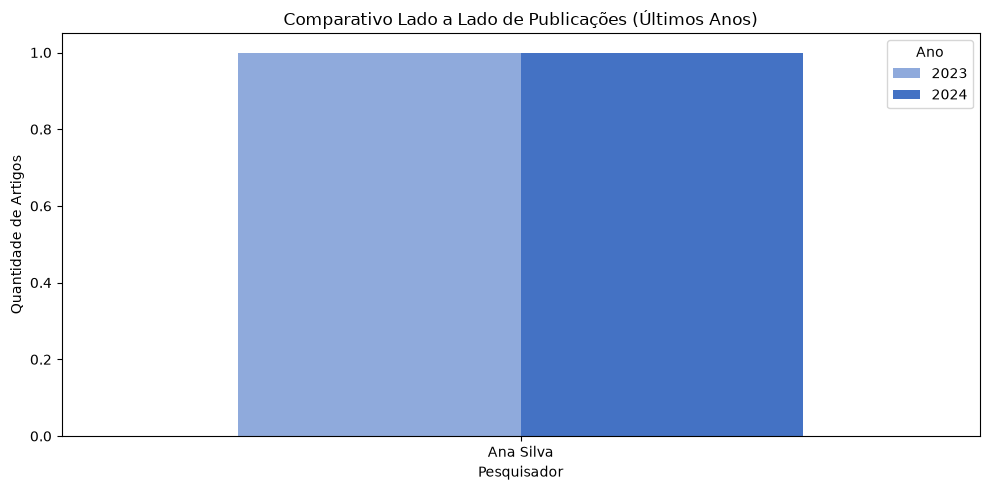

In [8]:
import matplotlib.pyplot as plt

# Monta matriz para barras agrupadas
matriz_barras = (
    df_agrupado.pivot(
        index=col_pesquisador, columns="ano", values="quantidade"
    )
    .fillna(0)
    .astype(int)
)

# Seleciona os últimos 3 anos para manter a comparação visual limpa
anos_recentes = matriz_barras.columns[-3:]
ax = matriz_barras[anos_recentes].plot(
    kind="bar", figsize=(10, 5), width=0.8, color=["#8FAADC", "#4472C4", "#0E4D92"]
)

plt.title("Comparativo Lado a Lado de Publicações (Últimos Anos)")
plt.xlabel("Pesquisador")
plt.ylabel("Quantidade de Artigos")
plt.legend(title="Ano")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Análise do Gráfico de Barras Agrupadas:**
* **Comparação Lado a Lado:** A disposição das barras permite comparar diretamente o volume de entregas entre pesquisadores no mesmo ano.
* **Tendência Recente:** Facilita identificar oscilações pontuais e checar a constância da produção acadêmica docente ano a ano.